In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pickle as pkl


In [4]:
warnings.filterwarnings('ignore')

In [5]:
# loading dataset
try:
    df = pd.read_csv('data/customers.csv')
except FileNotFoundError:
    print("Data set file nhi hai data folder me")
    exit()


In [6]:
df = pd.read_csv('data/customers.csv')

In [7]:
df.rename(columns={'Annual Income (k$)': 'Annual Income', 'Spending Score (1-100)': 'Spending Score'}, inplace=True)
df.sample(5)

,CustomerID,Gender,Age,Annual Income,Spending Score
107,108,Male,54,63,46
14,15,Male,37,20,13
31,32,Female,21,30,73
172,173,Male,36,87,10
160,161,Female,56,79,35


In [9]:
# preprocesing piplines

categorical_feature = ['Gender']
numerical_features = ['Age', 'Annual Income', 'Spending Score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feature)
    ]
)

new_df = df.drop('CustomerID', axis=1)

In [10]:
new_df.head()

,Gender,Age,Annual Income,Spending Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [11]:
# Fit preprocessor
new_df_processed = preprocessor.fit_transform(new_df)
# transforming data also


In [14]:
# same as a pickel file
with open('models/preprocessors.pkl', 'wb') as f:
    pkl.dump(preprocessor, f)

In [15]:
# Best k for applying k-mean using Elbow method

sse = []
k_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(new_df_processed)
    sse.append(kmeans.inertia_)


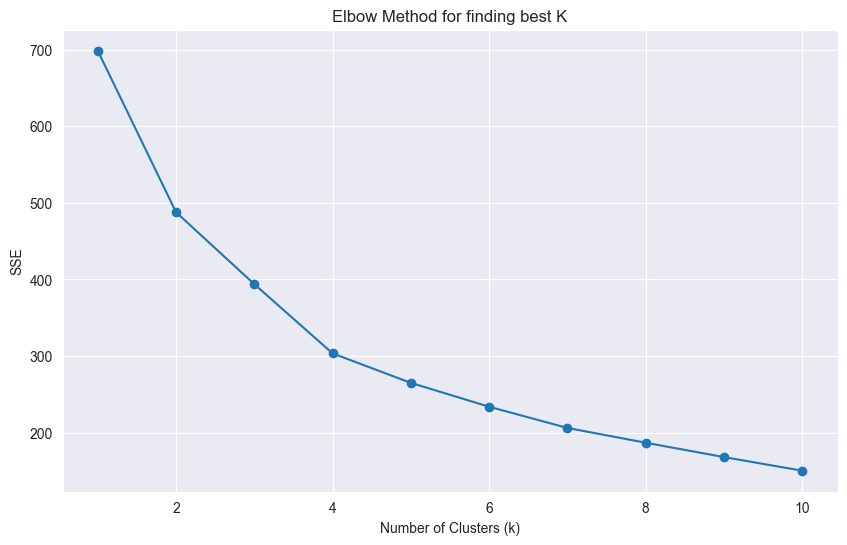

In [16]:
plt.figure(figsize = (10,6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for finding best K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.grid(True)
plt.savefig('models/elbow_method.png')
plt.show()


In [17]:
# will use k = 5 baed on typical elbow method oversation for this dataset

In [18]:
n_cluster = 5

models = {
    'KMeans' : KMeans(n_clusters=n_cluster, random_state=42, n_init=10),
    'AgglomerativeClustering': AgglomerativeClustering(n_clusters=n_cluster),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'GaussianMixture': GaussianMixture(n_components=n_cluster, random_state=42)
}

results = {}
fitted_modles = {}

In [24]:
for name, modle in models.items():
    if name == 'DBSCAN':
        clusters = modle.fit_predict(new_df_processed)
        mask = clusters != -1
        df_filtered = new_df_processed[mask]
        clusters_filtered = clusters[mask]
        if len(np.unique(clusters_filtered))>1:
            silhouette = silhouette_score(df_filtered, clusters_filtered)
            davies_bouldin = davies_bouldin_score(df_filtered, clusters_filtered)
            calinskin_harabaz = calinski_harabasz_score(df_filtered, clusters_filtered)
        else:
            silhouette = np.nan
            davies_bouldin = np.nan
            calinskin_harabaz = np.nan
    else:
        modle.fit(new_df_processed)
        clusters = modle.predict(new_df_processed) if hasattr(modle, 'predict') else modle.labels_
        silhouette = silhouette_score(new_df_processed, clusters)
        davies_bouldin = davies_bouldin_score(new_df_processed, clusters)
        calinskin_harabaz = calinski_harabasz_score(new_df_processed, clusters)

        results[name] = {
            'Davies-Bouldin Index': davies_bouldin,
            'Silhouette Score': silhouette,
            'Calinski-Harabaz Score': calinskin_harabaz,
        }
        fitted_modles[name] = modle

        # save the fitted model
        with open(f'models/{name.lower()}.pkl', 'wb') as f:
            pkl.dump(modle, f)

In [23]:
print(new_df_processed.shape)
print(clusters.shape)

(200, 5)
(200,)


In [25]:
# results
results_df = pd.DataFrame(results).T

In [26]:
results_df

,Davies-Bouldin Index,Silhouette Score,Calinski-Harabaz Score
KMeans,1.153338,0.315256,79.851848
AgglomerativeClustering,1.194445,0.314824,75.505278
GaussianMixture,1.394532,0.022402,15.753936


In [29]:
# Visualization using PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(new_df_processed)

# saving pca model)
with open('models/pca.pkl', 'wb') as f:
    pkl.dump(pca, f)

In [30]:
# visualisze clusters (Example with KMeans)
kmeans_model = fitted_modles['KMeans']
df['Cluster'] = kmeans_model.labels_

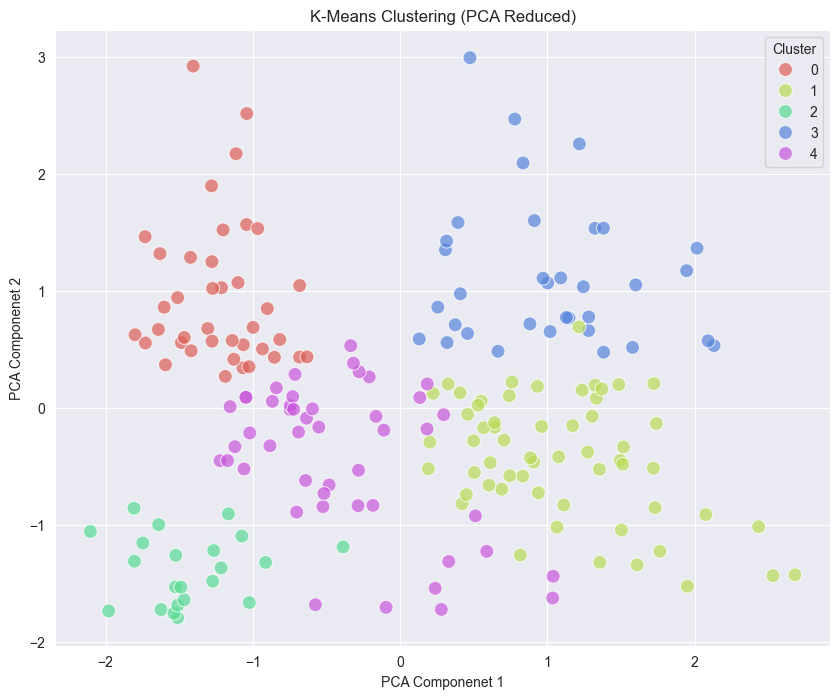

In [32]:
plt.figure(figsize = (10,8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df['Cluster'], palette=sns.color_palette('hls', n_colors=n_cluster),
                s = 100, alpha=0.7)
plt.title("K-Means Clustering (PCA Reduced)")
plt.xlabel('PCA Componenet 1')
plt.ylabel('PCA Componenet 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.savefig('models/kmeans_pca_clusters.png')
plt.show()

In [33]:
cluster_means = df.groupby('Cluster')[numerical_features].mean()

In [34]:
# K-means cluster means:
cluster_means

,Age,Annual Income,Spending Score
Cluster,,,
0,32.692308,86.538462,82.128205
1,55.551724,48.482759,41.775862
2,25.272727,25.727273,79.363636
3,41.264706,88.500000,16.764706
4,27.957447,50.000000,44.638298
